In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving House Price India.csv to House Price India.csv


In [7]:
df = pd.read_csv("House Price India.csv")
print(df.columns)

Index(['id', 'Date', 'No of bedrooms', 'No of bathrooms', 'living area',
       'lot area', 'No of floors', 'waterfront present', 'No of views',
       'house condition', 'house grade', 'house area(excluding basement)',
       'Area of the basement', 'Built Year', 'Renovation Year', 'Postal Code',
       'Lattitude', 'Longitude', 'living_area_renov', 'lot_area_renov',
       'No of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')


In [8]:
df = df[["living area","Price"]]
print(df)

       living area    Price
0             2920  1400000
1             2910  1200000
2             3310   838000
3             2710   805000
4             2600   790000
...            ...      ...
14614         1556   221700
14615         1680   219200
14616         1070   209000
14617         1030   205000
14618          900   146000

[14619 rows x 2 columns]


[ 0.88542843  0.87465474  1.30560238 ... -1.10770444 -1.1507992
 -1.29085719]
[ 2.34519151  1.80055412  0.81476043 ... -0.89812417 -0.90901692
 -1.06968495]


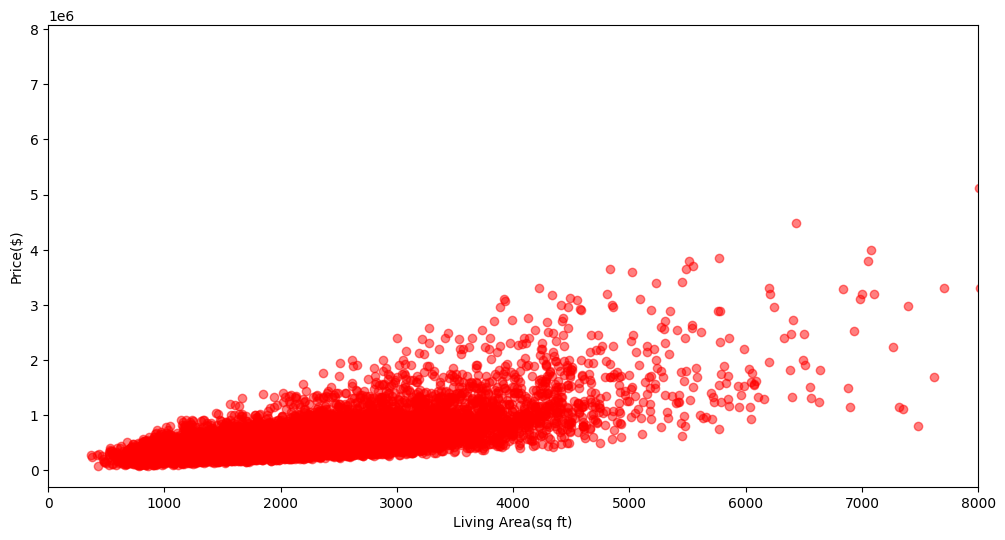

In [9]:
x_train = df[["living area"]]
y_train = df[["Price"]]
plt.figure(figsize=(12,6))
plt.scatter(x_train,y_train,color="r",alpha=0.5)
plt.xlim(0,8000)
plt.xlabel("Living Area(sq ft)")
plt.ylabel("Price($)")
x_train = x_train.to_numpy().flatten()
y_train = y_train.to_numpy().flatten()
x_mean = x_train.mean()
x_std = x_train.std()
x_mean = x_train.mean()
x_std = x_train.std()
x_train = (x_train-x_mean)/x_std
y_mean = y_train.mean()
y_std = y_train.std()
y_train = (y_train-y_mean)/y_std
print(x_train)
print(y_train)

In [10]:
m = len(x_train)
print(f"Number of Training Examples: {m}")

Number of Training Examples: 14619


In [11]:
def compute_cost(x,y,w,b):
  m = len(x)
  cost = 0
  for i in range(m):
    f_wb = w*x[i]+b
    cost_sum = (f_wb-y[i])**2
    cost+=cost_sum
  cost = cost/(2*m)
  return cost


In [12]:
def compute_descent(x,y,w,b):
  dj_dw=0
  dj_db=0
  m = len(x)
  for i in range(m):
    f_wb = w*x[i]+b
    dj_dw_i = (f_wb-y[i])*x[i]
    dj_db_i = (f_wb-y[i])
    dj_dw+=dj_dw_i
    dj_db+=dj_db_i
  dj_dw = dj_dw/m
  dj_db = dj_db/m
  return dj_dw,dj_db


In [13]:
def gradient_descent(x,y,w_in,b_in,it,alpha):
  w=w_in
  b=b_in
  cost_history = []
  for i in range(it):
    dj_dw,dj_db = compute_descent(x,y,w,b)
    w=w-alpha*dj_dw
    b=b-alpha*dj_db
    cost_history.append(compute_cost(x,y,w,b))
  return w,b,cost_history

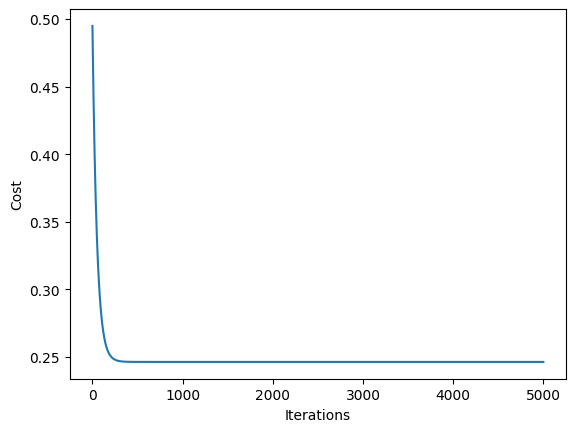

In [14]:
w_init = 0
b_init = 0
iterations = 5000
alpha = 0.01
w_final,b_final,cost_history = gradient_descent(x_train,y_train,w_init,b_init,iterations,alpha)
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

In [15]:
print(w_final,b_final)

0.7122762653325123 1.6674328652891678e-16


In [16]:
print(compute_cost(x_train,y_train,w_final,b_final))

0.2463312609219793


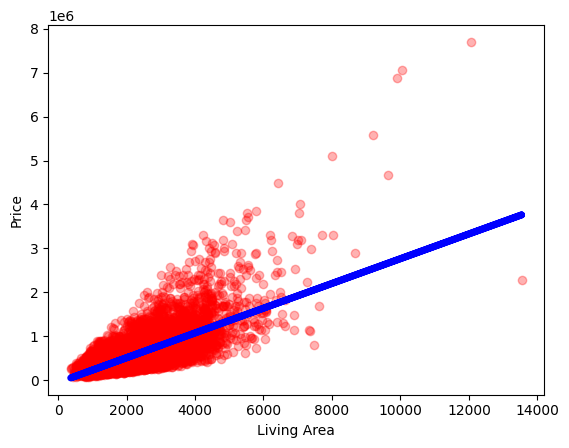

In [24]:
m = len(x_train)
pred_price = []
livingArea = []
price = []
for i in range(m):
  livingArea.append(x_train[i]*x_std+x_mean)
  price.append(y_train[i]*y_std+y_mean)
  y=w_final*x_train[i]+b_final
  y=y*y_std+y_mean
  pred_price.append(y)
plt.plot(livingArea,pred_price,color="b",lw=5)
plt.scatter(livingArea,price,color="r",alpha=0.3)
plt.xlabel("Living Area")
plt.ylabel("Price")
plt.show()


In [25]:
x = int(input("Enter Size of house in Sq. Ft: "))
x = (x-x_mean)/x_std
y = w_final*x+b_final
y = y*y_std+y_mean
print(f"Price of house is {y}")

Enter Size of house in Sq. Ft: 500
Price of house is 88451.33682985336
